## **Data Preprocessing**

In [2]:
# import necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# Read the dataset
df = pd.read_csv("UMACT_HACKATHON_2026_FINALVERSION.csv")

In [4]:
# Get insights from the dataset
df.head(5)

,claim_id,policyholder_id,patient_age,patient_gender,smoker_status,bmi,chronic_conditions,has_previous_claims,plan_type,room_and_board_limit,...,procedure_diagnosis,doctor_fees,hospital_charges,medication_cost,investigation_cost,total_claim_amount,rb_entitlement_total,patient_co_payment,insurance_paid,hits_cap
0,MHC0000001,PH02843,4,F,Non-Smoker,27.1,0,0,Gold,350,...,Dengue Haemorrhagic Fever,1555.25,3393.28,1272.48,848.32,7069.33,1750,1413.87,5655.46,False
1,MHC0000002,PH07593,33,M,Non-Smoker,15.2,0,0,Basic,150,...,Asthma Exacerbation,6179.34,13482.19,5055.82,3370.55,28087.90,750,3000.00,25087.90,True
2,MHC0000003,PH00983,1,M,Non-Smoker,27.6,0,0,Basic,150,...,Asthma Exacerbation,6789.39,14813.21,5554.95,3703.30,30860.85,900,3000.00,27860.85,True
3,MHC0000004,PH03707,33,F,Non-Smoker,30.2,0,0,Silver,250,...,Normal Delivery,6137.88,13391.75,5021.90,3347.94,27899.47,750,3000.00,24899.47,True
4,MHC0000005,PH05756,17,M,Non-Smoker,30.4,0,0,Gold,350,...,Dengue Haemorrhagic Fever,1379.66,3010.17,1128.81,752.54,6271.18,1400,1254.24,5016.94,False


In [5]:
# Basic info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   claim_id              20000 non-null  object 
 1   policyholder_id       20000 non-null  object 
 2   patient_age           20000 non-null  int64  
 3   patient_gender        20000 non-null  object 
 4   smoker_status         20000 non-null  object 
 5   bmi                   20000 non-null  float64
 6   chronic_conditions    20000 non-null  int64  
 7   has_previous_claims   20000 non-null  int64  
 8   plan_type             20000 non-null  object 
 9   room_and_board_limit  20000 non-null  int64  
 10  patient_state         20000 non-null  object 
 11  region                20000 non-null  object 
 12  hospital_name         20000 non-null  object 
 13  hospital_type         20000 non-null  object 
 14  admission_type        20000 non-null  object 
 15  admission_date     

In [6]:
# Get insight of central tendency and statistical value
df.describe()

,patient_age,bmi,chronic_conditions,has_previous_claims,room_and_board_limit,length_of_stay,doctor_fees,hospital_charges,medication_cost,investigation_cost,total_claim_amount,rb_entitlement_total,patient_co_payment,insurance_paid
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,19700.000000,20000.000000,20000.000000,20000.000000,19560.000000,20000.000000,20000.00000,19400.000000,20000.000000
mean,41.810350,27.094455,1.010650,0.568250,259.240000,5.289391,12932.382046,28216.106208,10581.039794,7046.988376,58783.554600,1379.04000,2765.943685,56018.296644
std,24.526397,6.176665,1.129469,0.495332,121.038651,2.096330,12629.930747,27556.212625,10333.579744,6888.599356,57408.776245,876.63225,535.185731,57202.072675
min,0.000000,12.000000,0.000000,0.000000,150.000000,-10.000000,905.870000,1976.430000,741.160000,494.110000,4117.570000,150.00000,823.510000,3294.060000
25%,20.000000,23.200000,0.000000,0.000000,150.000000,4.000000,4730.850000,10321.865000,3870.695000,2575.740000,21503.877500,750.00000,3000.000000,18503.877500
50%,42.000000,26.700000,1.000000,1.000000,250.000000,5.000000,7109.970000,15512.655000,5817.245000,3875.010000,32318.035000,1200.00000,3000.000000,29318.035000
75%,63.000000,30.500000,2.000000,1.000000,350.000000,7.000000,19652.085000,42877.285000,16078.982500,10702.247500,89327.670000,1750.00000,3000.000000,86327.670000
max,84.000000,65.000000,4.000000,1.000000,550.000000,14.000000,55000.000000,120000.000000,45000.000000,30000.000000,250000.000000,6600.00000,3000.000000,247000.000000


In [7]:
# Check the number of each missing value in each column
df.isna().sum()

claim_id                  0
policyholder_id           0
patient_age               0
patient_gender            0
smoker_status             0
bmi                       0
chronic_conditions        0
has_previous_claims       0
plan_type                 0
room_and_board_limit      0
patient_state             0
region                    0
hospital_name             0
hospital_type             0
admission_type            0
admission_date            0
discharge_date          300
length_of_stay          300
major_category          700
sub_category              0
procedure_diagnosis       0
doctor_fees               0
hospital_charges          0
medication_cost           0
investigation_cost      440
total_claim_amount        0
rb_entitlement_total      0
patient_co_payment      600
insurance_paid            0
hits_cap                  0
dtype: int64

In [8]:
# Check whether there are any duplicated row in the dataset
df.duplicated().sum()

np.int64(0)

In [9]:
# Filling in null values for major_category by inferring the values of sub_category and procedure_diagnosis
mapping = (
    df[df['major_category'].notna()]
    .groupby(['sub_category', 'procedure_diagnosis'])['major_category']
    .agg(lambda x: x.mode()[0])  # most frequent value
)

def fill_major(row):
    if pd.isna(row['major_category']):
        key = (row['sub_category'], row['procedure_diagnosis'])
        return mapping.get(key, np.nan)
    return row['major_category']

df['major_category'] = df.apply(fill_major, axis=1)

# Filling in null values in the investigation_cost by applying the formula investigation_cost = total_claim_amount - doctor_fees - hospital_charges - medication_cost
df['investigation_cost'] = df['investigation_cost'].fillna(
    df['total_claim_amount']
    - df['doctor_fees']
    - df['hospital_charges']
    - df['medication_cost']
)

# Filling in null values in the patient_co_payment by applying the formula, patient_co_payment = total_claim_amount * 0.2, capped at RM3000
df['patient_co_payment'] = df['patient_co_payment'].fillna(
    df['total_claim_amount'] * 0.2).clip(upper=3000)

# Filling in null values in the length_of_stay by referring the formula, length_of_stay = rb_entitlement_total/room_and_board_limit
df['length_of_stay'] = df['length_of_stay'].fillna(
    df['rb_entitlement_total'] / df['room_and_board_limit']
)

# Filling in the null values in the discharge_date by referring the formula, discharge_date = admission_date + length_of_stay
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

df.loc[df['discharge_date'].isna(), 'discharge_date'] = (
    df['admission_date'] + pd.to_timedelta(df['length_of_stay'], unit='D')
)

df.isna().sum()

claim_id                0
policyholder_id         0
patient_age             0
patient_gender          0
smoker_status           0
bmi                     0
chronic_conditions      0
has_previous_claims     0
plan_type               0
room_and_board_limit    0
patient_state           0
region                  0
hospital_name           0
hospital_type           0
admission_type          0
admission_date          0
discharge_date          0
length_of_stay          0
major_category          0
sub_category            0
procedure_diagnosis     0
doctor_fees             0
hospital_charges        0
medication_cost         0
investigation_cost      0
total_claim_amount      0
rb_entitlement_total    0
patient_co_payment      0
insurance_paid          0
hits_cap                0
dtype: int64

In [10]:
# From the dataset, if the length_of_stay is negative, switch the value of admission_date and discharge_date and change the negative value to positive
mask = df['length_of_stay'] < 0

df.loc[mask, ['admission_date', 'discharge_date']] = df.loc[mask, ['discharge_date', 'admission_date']].values

df.loc[mask, 'length_of_stay'] = df.loc[mask, 'length_of_stay'].abs()

## **Exploratory Data Analysis (EDA)**

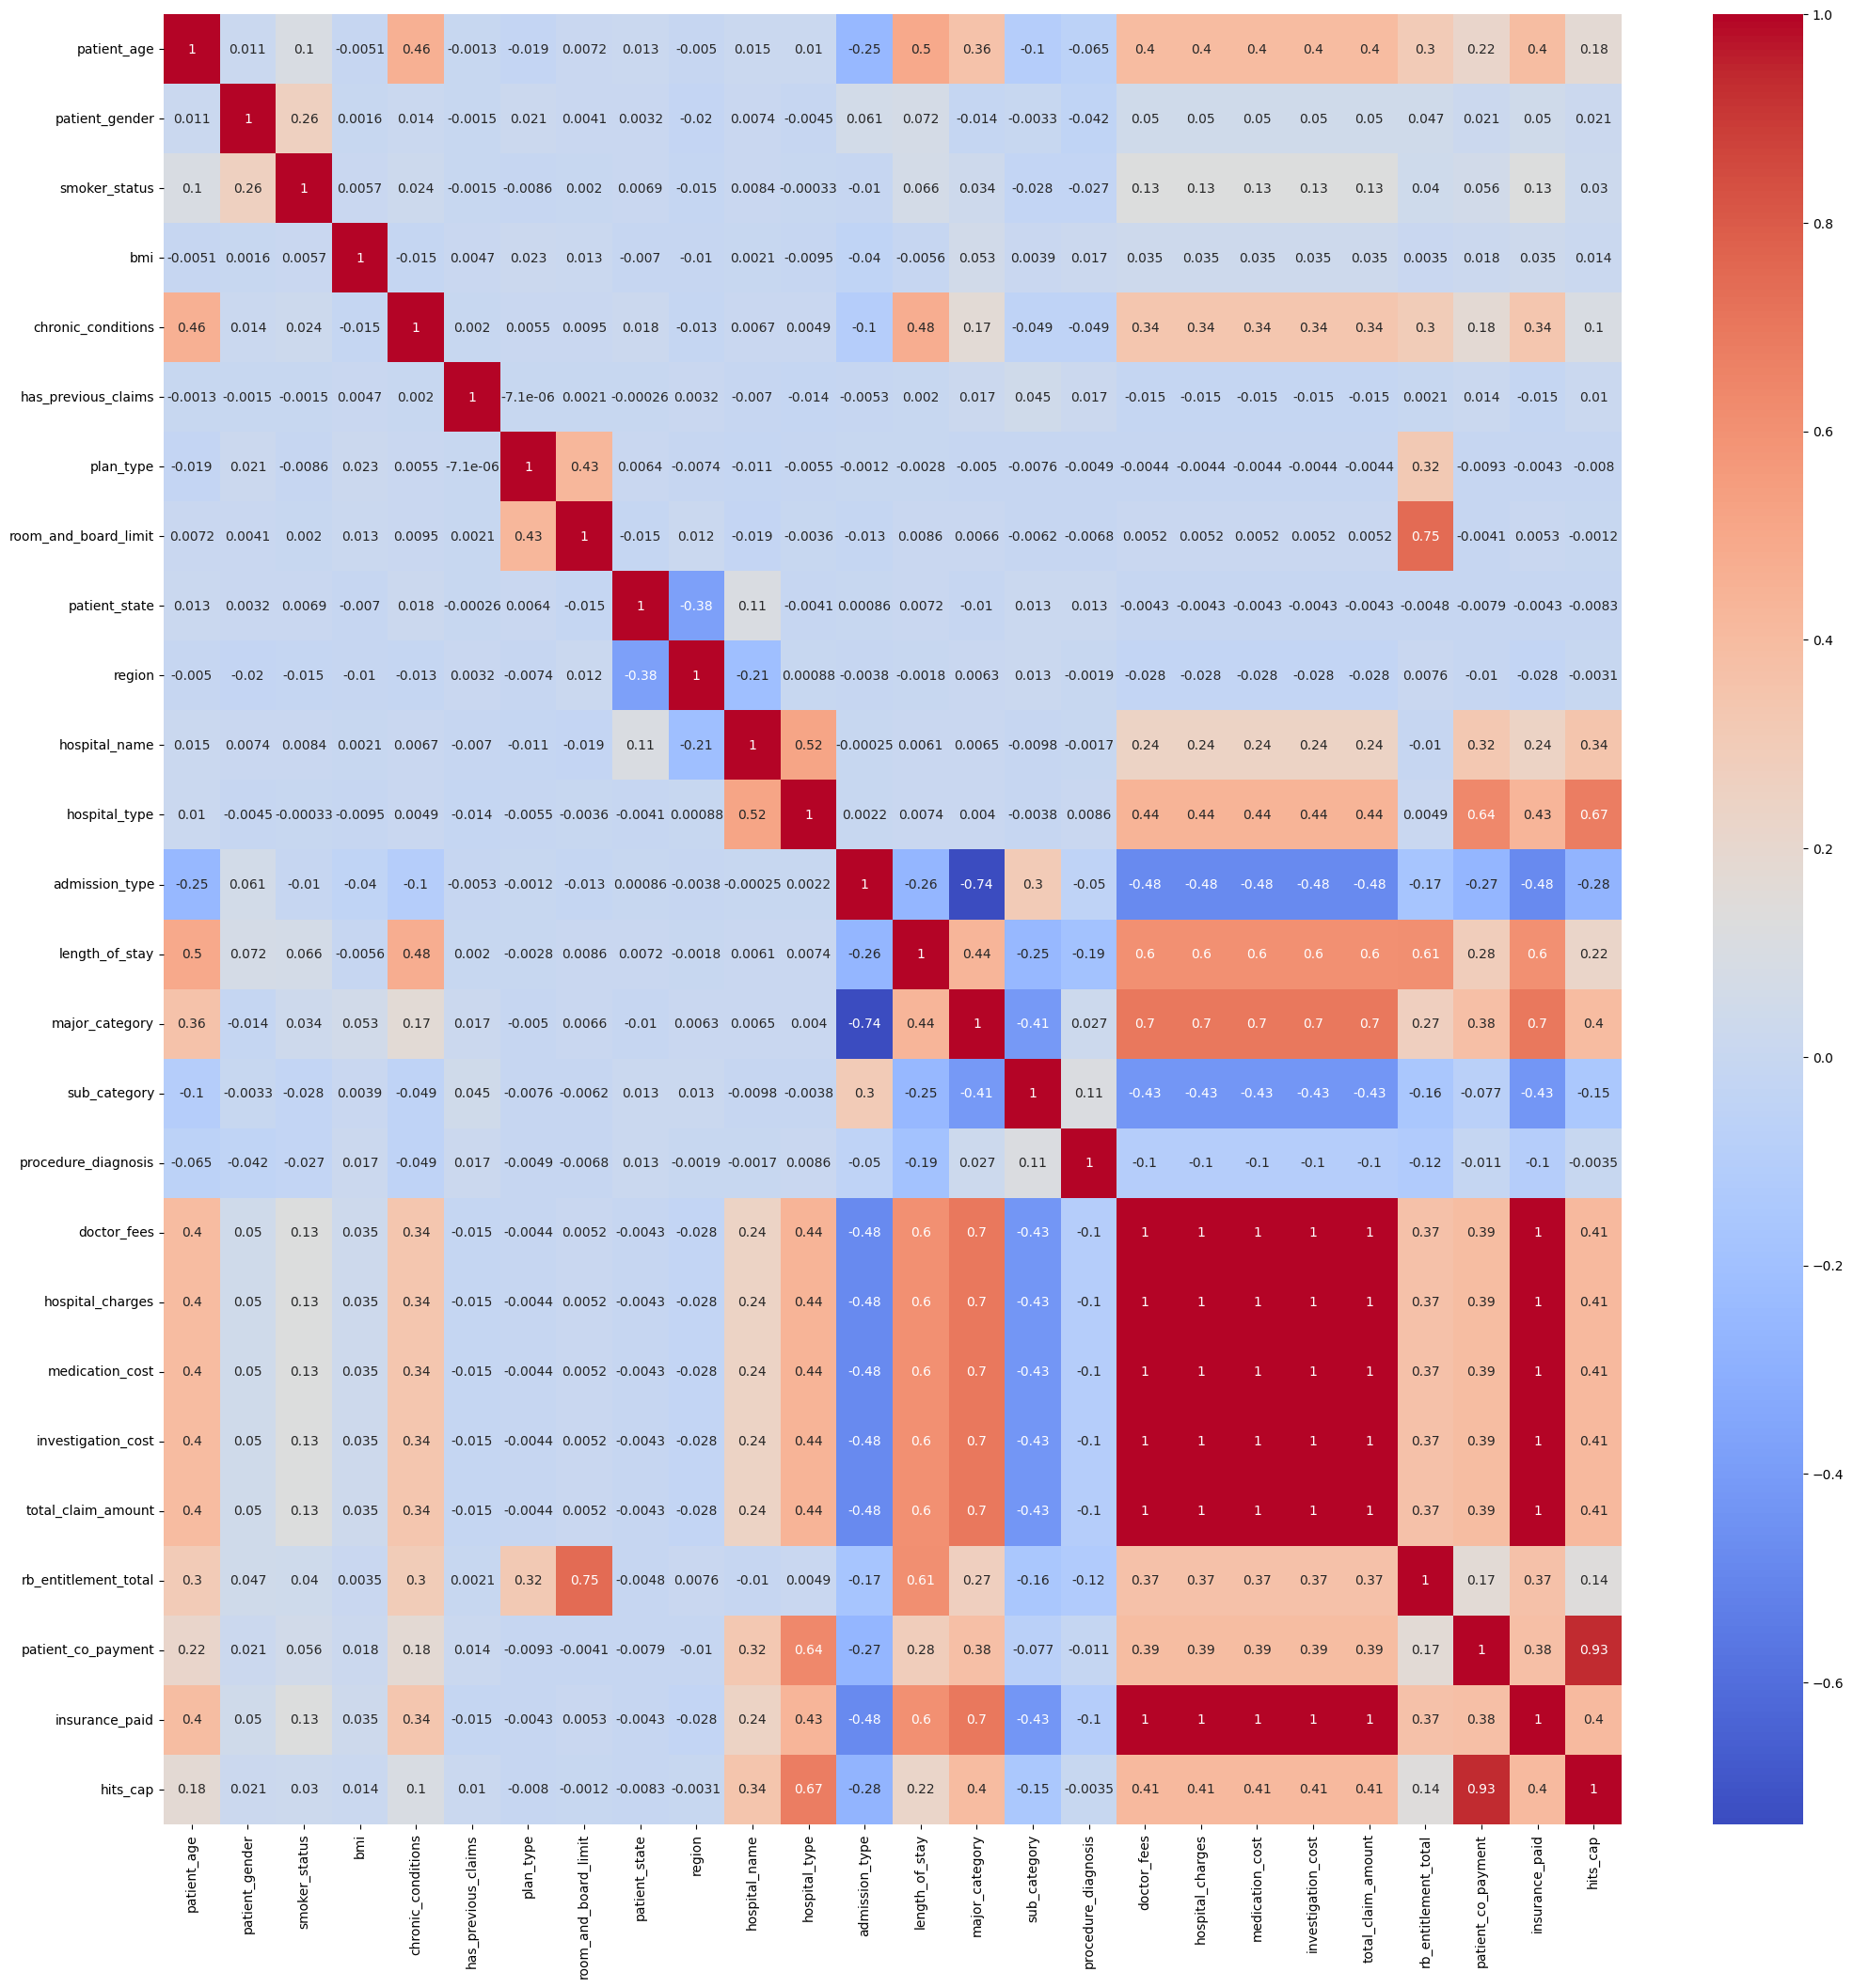

In [11]:
# Correlation matrix

# Create a copy
df_processed = df.copy()

# Drop IDs
df_processed = df_processed.drop(['claim_id', 'policyholder_id'], axis=1)

# Convert boolean
df_processed['hits_cap'] = df_processed['hits_cap'].astype(int)

df_processed['patient_gender'] = df_processed['patient_gender'].map({
    'M': 1,
    'F': 0
})

df_processed['smoker_status'] = df_processed['smoker_status'].map({
    'Smoker': 1,
    'Non-Smoker': 0
})

from sklearn.preprocessing import LabelEncoder

label_encoders = {} 

cols = [
    'plan_type',
    'patient_state',
    'region',
    'hospital_name',
    'hospital_type',
    'admission_type',
    'major_category',
    'sub_category',
    'procedure_diagnosis'
]

for col in cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    
    label_encoders[col] = le

# Drop date columns
df_processed = df_processed.drop(['admission_date', 'discharge_date'], axis=1)

# Heatmap
plt.figure(figsize=(25,25))
sns.heatmap(df_processed.corr(), annot = True, cmap='coolwarm')
plt.show()



The strong correlations among cost-related variables indicate multicollinearity, as these features capture overlapping information about total medical expenses. This suggests redundancy in the dataset, where multiple variables represent different components of the same underlying cost structure.

In [12]:
all_mappings = []

for col, le in label_encoders.items():
    encoded_values = le.transform(le.classes_).astype(int)
    
    df_temp = pd.DataFrame({
        'Column': col,
        'Label': le.classes_,
        'Encoded_Value': encoded_values
    })
    all_mappings.append(df_temp)

final_df = pd.concat(all_mappings, ignore_index=True)

final_df.head(10)

,Column,Label,Encoded_Value
0,plan_type,Basic,0
1,plan_type,Gold,1
2,plan_type,Platinum,2
3,plan_type,Silver,3
4,patient_state,Johor,0
5,patient_state,Kedah,1
6,patient_state,Kelantan,2
7,patient_state,Kuala Lumpur,3
8,patient_state,Labuan,4
9,patient_state,Melaka,5


In [13]:
from matplotlib.ticker import FuncFormatter
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_d")
def comma_format(x, pos):
    return f'{x:,.0f}'
formatter = FuncFormatter(comma_format)

In [14]:
bins = [0, 17, 35, 50, 65, float('inf')]
labels = ["Child (0-17)", "Young Adult (18-35)", "Middle Age (36-50)", "Senior (51-65)", "Elderly (66+)"]

df['age_group'] = pd.cut(
    df['patient_age'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True)

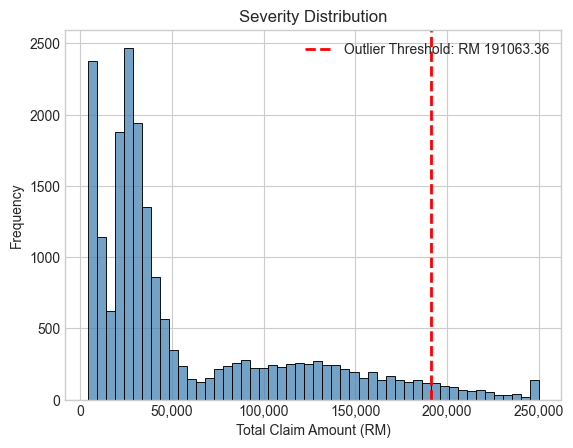

In [15]:
# Claim severity distribution

# calculate the outlier threshold using the IQR method
Q1 = df['total_claim_amount'].quantile(0.25)
Q3 = df['total_claim_amount'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR

# histogram with the outlier threshold
sns.histplot(df['total_claim_amount'], bins=50, color='steelblue', kde=False) 
plt.axvline(outlier_threshold, color='red', linestyle='--', linewidth=2, label=f'Outlier Threshold: RM {outlier_threshold:.2f}')
plt.gca().xaxis.set_major_formatter(formatter) 
plt.title("Severity Distribution")
plt.xlabel("Total Claim Amount (RM)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

A strong right-skewed distribution of claim severity indicates that the majority of claims are concentrated at lower cost levels. However, a small number of high-cost cases may be driven by differences in treatment complexity, hospital type and underlying patient conditions. The significant variance in medical costs highlights that risk-based pricing and customer segmentation are necessary to develop cost-controlled policies for financial sustainability and affordability.

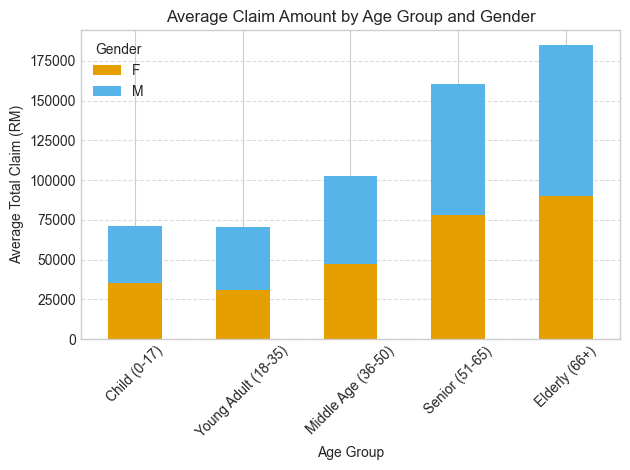

In [16]:
# Demographic Trends

# group data by age group and gender, then convert to wide format for plotting
demo_summary = df.groupby(['age_group', 'patient_gender'], observed=False)['total_claim_amount'].mean().unstack()

# Stacked bar chart for average claim amount
demo_summary.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#E69F00', '#56B4E9'])
plt.title("Average Claim Amount by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Average Total Claim (RM)")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The total gross medical bill increase significantly with age, with noticeable spike that is at least 2 times higher than young-adult group for senior and elderly patients. Males show slightly higher claim frequency than females across all age groups, but the difference is negligible compared to the impact of age. This suggests that gender-based premium adjustments would yield marginal gains in risk accuracy compared to age-based tiering system. 

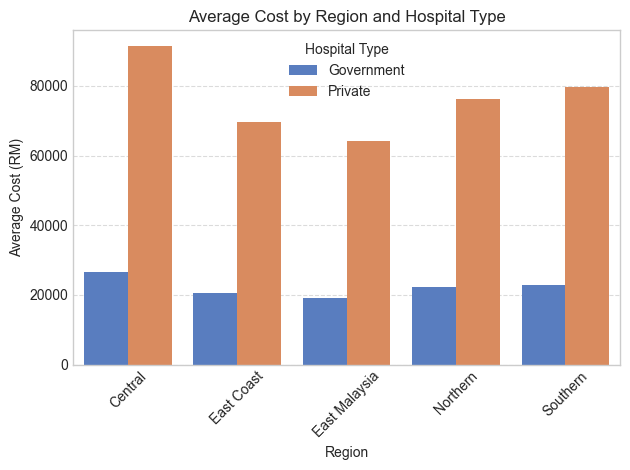

In [17]:
# Regional brenchmark

# group data by region and hospital type
regional_summary = df.groupby(['region', 'hospital_type'], observed=False).agg(
    avg_cost=('total_claim_amount', 'mean'),
    count=('total_claim_amount', 'size')).reset_index()

# bar plot
sns.barplot(
    data=regional_summary, 
    x='region', 
    y='avg_cost', 
    hue='hospital_type',
    palette="muted")

plt.title("Average Cost by Region and Hospital Type")
plt.xlabel("Region")
plt.ylabel("Average Cost (RM)")
plt.xticks(rotation=45)
plt.legend(title="Hospital Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The regional analysis shows that private hospitals in Malaysia are significantly more costly than government facilities, likely driven by private-sector pricing models. The Central region recorded the highest costs that reflect increasing medical inflation caused by high demand and usage of advanced medical technology, while East Malaysia shows the lowest cost, that may due to limited accessibility and lower demand of specialized medical services in those states. 

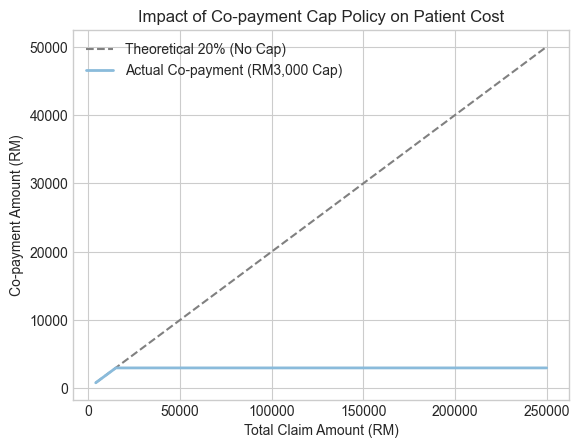

In [18]:
# Co-payment Cap Policy Impact

# theoretical co-payment without cap
sns.lineplot(x='total_claim_amount', y=df['total_claim_amount'] * 0.2, data=df,
             label='Theoretical 20% (No Cap)', linestyle='--', color='gray')
# actual co-payment with policy cap 
sns.lineplot(x='total_claim_amount', y=df['patient_co_payment'], data=df, 
             label='Actual Co-payment (RM3,000 Cap)', linewidth=2)

plt.title("Impact of Co-payment Cap Policy on Patient Cost")
plt.xlabel("Total Claim Amount (RM)")
plt.ylabel("Co-payment Amount (RM)")
plt.legend()
plt.show()

This policy does not designed for minor treatments that are affordable. The RM3000 co-payment cap significantly reduces financial burden for high-cost patients that claims exceed RM15000 threshold; however it may be costly for insurers if the policy does not accompanied by standardized cost-control measures, leading to risk of over-utilization of healthcare services. 

## **Clustering Analysis for DRG-related grouping**

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [20]:
cluster_features = ['chronic_conditions', 'doctor_fees', 'hospital_charges', 
                    'investigation_cost', 'medication_cost']

In [21]:
# standardize
X = df[cluster_features].copy()
X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

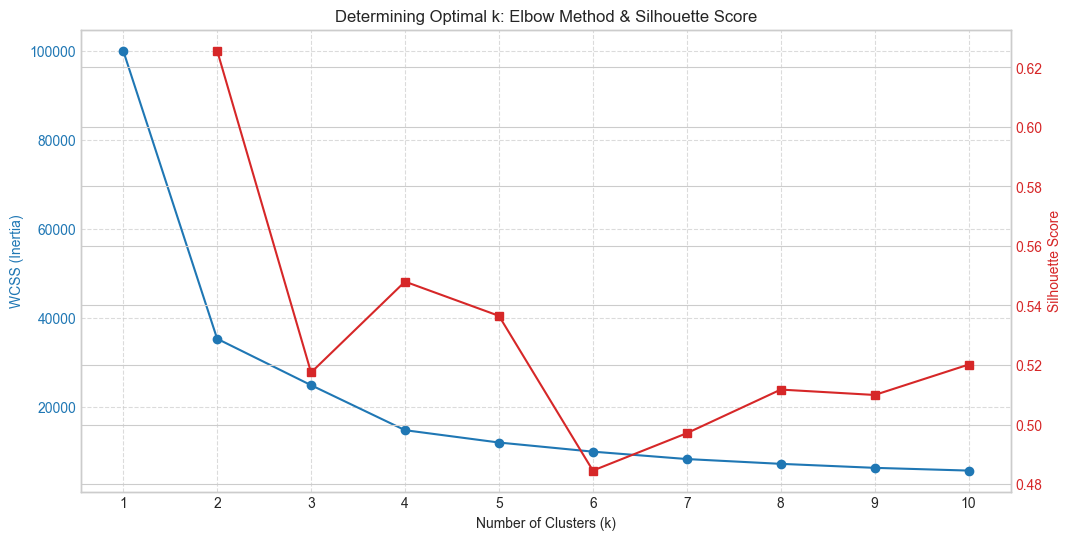

In [22]:
from sklearn.metrics import silhouette_score

# Initialize lists
wcss = [] 
silhouette_avg = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # 1. WCSS (Elbow Method)
    wcss.append(kmeans.inertia_)
    
    # 2. Silhouette Score (Only for k > 1)
    if k > 1:
        score = silhouette_score(X_scaled, cluster_labels)
        silhouette_avg.append(score)
    else:
        silhouette_avg.append(None) # Placeholder for k=1

# --- Visualization ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot WCSS (Left Axis)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='tab:blue')
ax1.plot(k_range, wcss, marker='o', linestyle='-', color='tab:blue', label='WCSS')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis for Silhouette Score (Right Axis)
ax2 = ax1.twinx() 
ax2.set_ylabel('Silhouette Score', color='tab:red')
# Start plotting from index 1 (k=2) to skip the None value
ax2.plot(list(k_range)[1:], silhouette_avg[1:], marker='s', linestyle='-', color='tab:red', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Determining Optimal k: Elbow Method & Silhouette Score')
ax1.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_range)
plt.show()

In [23]:
# K-means clustering with the chosen k = 4
kmeans = KMeans(n_clusters= 4, random_state=42)
df['DRG_Proxy_Cluster'] = kmeans.fit_predict(X_scaled)

# clustering summary with median values for claim_amount and length_of_stay
cluster_summary = df.groupby('DRG_Proxy_Cluster')[cluster_features + ['total_claim_amount'] + ['length_of_stay']].median()
print("=== Cluster Center ===")
print(cluster_summary)

# major category and procedure_diagnosis distribution in each cluster
print("=== Major Category in Each Cluster ===")
top_major = df.groupby('DRG_Proxy_Cluster')['major_category'].value_counts().groupby(level=0).head(3)
print(top_major)

print("\n" + "="*50 + "\n")

# top 3 procedure diagnosis in each cluster
print("=== Top 3 Procedure Diagnoses in Each Cluster ===")
# group by cluster and count the occurrences of each procedure diagnosis
top_diagnosis = df.groupby('DRG_Proxy_Cluster')['procedure_diagnosis'].value_counts().groupby(level=0).head(3)
print(top_diagnosis)

=== Cluster Center ===
                   chronic_conditions  doctor_fees  hospital_charges  \
DRG_Proxy_Cluster                                                      
0                                 2.0     8239.430          17976.94   
1                                 2.0    39930.400          87120.87   
2                                 0.0     5288.090          11537.64   
3                                 1.0    24358.605          53146.05   

                   investigation_cost  medication_cost  total_claim_amount  \
DRG_Proxy_Cluster                                                            
0                            4494.230         6741.350            37451.95   
1                           21780.220        32670.330           181501.82   
2                            2884.415         4326.615            24036.76   
3                           13286.510        19929.765           110720.93   

                   length_of_stay  
DRG_Proxy_Cluster                  
0  

In [24]:
# K-means clustering with the chosen k = 5
kmeans = KMeans(n_clusters= 5, random_state=42)
df['DRG_Proxy_Cluster'] = kmeans.fit_predict(X_scaled)

# clustering summary with median values for claim_amount and length_of_stay
cluster_summary = df.groupby('DRG_Proxy_Cluster')[cluster_features + ['total_claim_amount'] + ['length_of_stay']].median()
print("=== Cluster Center ===")
print(cluster_summary)

# major category and procedure_diagnosis distribution in each cluster
print("=== Major Category in Each Cluster ===")
top_major = df.groupby('DRG_Proxy_Cluster')['major_category'].value_counts().groupby(level=0).head(3)
print(top_major)

print("\n" + "="*50 + "\n")

# top 3 procedure diagnosis in each cluster
print("=== Top 3 Procedure Diagnoses in Each Cluster ===")
# group by cluster and count the occurrences of each procedure diagnosis
top_diagnosis = df.groupby('DRG_Proxy_Cluster')['procedure_diagnosis'].value_counts().groupby(level=0).head(3)
print(top_diagnosis)

=== Cluster Center ===
                   chronic_conditions  doctor_fees  hospital_charges  \
DRG_Proxy_Cluster                                                      
0                                 2.0     8218.140         17930.480   
1                                 1.0    31171.915         68011.445   
2                                 0.0     5274.830         11508.710   
3                                 0.0    20799.000         45379.630   
4                                 2.0    43973.025         95941.145   

                   investigation_cost  medication_cost  total_claim_amount  \
DRG_Proxy_Cluster                                                            
0                             4482.62          6723.93            37355.17   
1                            17002.86         25504.29           141690.51   
2                             2877.18          4315.77            23976.49   
3                            11344.91         17017.36            94540.90   
4   

In [25]:
cluster_order = df.groupby('DRG_Proxy_Cluster')['total_claim_amount'].median().sort_values().index

mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_order)}

df['Ordered_DRG_Group'] = df['DRG_Proxy_Cluster'].map(mapping)
df_processed['Ordered_DRG_Group'] = df['Ordered_DRG_Group']

print(df.groupby('Ordered_DRG_Group')['total_claim_amount'].median())

Ordered_DRG_Group
0     23976.49
1     37355.17
2     94540.90
3    141690.51
4    199877.39
Name: total_claim_amount, dtype: float64


## **Total Claim Cost Prediction Model**

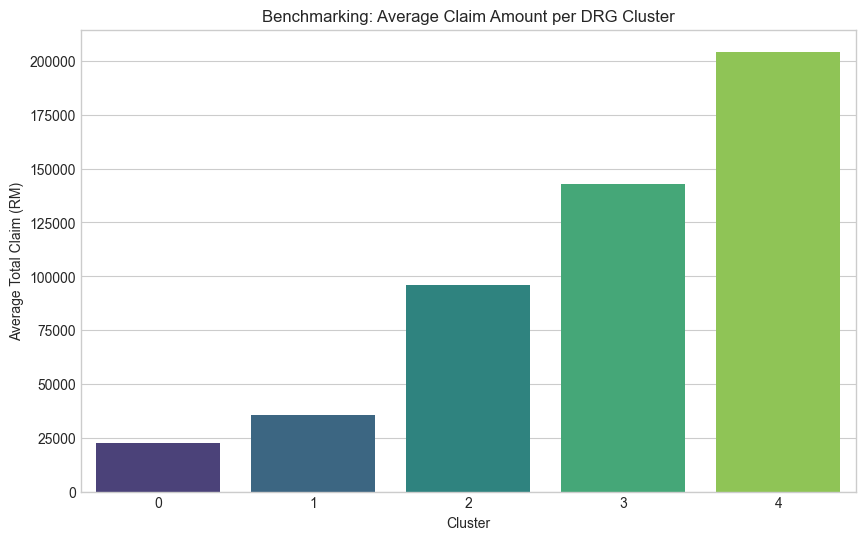

   Cluster      Avg_Claim  Median_Claim  Std_Dev_Claim  Max_Claim   Avg_LOS  \
0        0   22620.129164      23976.49   11019.262867   58831.90  4.255362   
1        1   35769.976449      37355.17   16782.116457  102104.07  6.425271   
2        2   95855.658451      94540.90   16807.592396  132759.73  5.011036   
3        3  142737.055335     141690.51   18982.073172  195865.72  6.899914   
4        4  204313.307979     199877.39   24869.721618  250000.00  8.628247   

   Median_LOS  Claim_Count  
0         4.0        10491  
1         6.0         3593  
2         5.0         2356  
3         7.0         2328  
4         9.0         1232  


In [26]:
# 1. Calculate Benchmarks per DRG Cluster
drg_benchmarks = df.groupby('Ordered_DRG_Group').agg({
    'total_claim_amount': ['mean', 'median', 'std', 'max'],
    'length_of_stay': ['mean', 'median'],
    'claim_id': 'count'
}).reset_index()

# Rename columns for clarity
drg_benchmarks.columns = ['Cluster', 'Avg_Claim', 'Median_Claim', 'Std_Dev_Claim', 'Max_Claim', 'Avg_LOS', 'Median_LOS', 'Claim_Count']

# 2. Visualize the Benchmarks
plt.figure(figsize=(10, 6))
sns.barplot(data=drg_benchmarks, x='Cluster', y='Avg_Claim', palette='viridis')
plt.title('Benchmarking: Average Claim Amount per DRG Cluster')
plt.ylabel('Average Total Claim (RM)')
plt.show()

print(drg_benchmarks)

In [27]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# --- STEP 1: Feature Prep for Individual Prediction ---
# We use the DRG_Group (the ordered one) + the individual's profile
features_for_model = [
    'patient_age', 'bmi', 'chronic_conditions', 'length_of_stay', 
    'patient_gender', 'smoker_status', 'region', 'hospital_type', 'Ordered_DRG_Group'
]

# Create X (features) and y (target)
X = df_processed[features_for_model]
y = df_processed['total_claim_amount']

# --- STEP 2: Entry-by-Entry Prediction ---
# We train on the whole set to establish the "standard" and then predict back onto it
rf_regressor = RandomForestRegressor(n_estimators=200, random_state=42)
rf_regressor.fit(X, y)

# Generate a unique "Supposed Amount" for every single row
df_processed['supposed_claim_amount'] = rf_regressor.predict(X)

# --- STEP 3: Individual Comparison Calculation ---
# Calculate how much each specific person was over/undercharged
df_processed['variance_amount'] = df_processed['total_claim_amount'] - df_processed['supposed_claim_amount']
df_processed['variance_percentage'] = (df_processed['variance_amount'] / df_processed['supposed_claim_amount']) * 100

# Define an overcharge threshold (e.g., more than 15% above the predicted price)
df_processed['is_overcharged'] = df_processed['variance_percentage'] > 15

# --- STEP 4: View the Resulting Table ---
# This shows you the specific entries that are problematic
overcharged_list = df_processed[df_processed['is_overcharged'] == True][
    ['procedure_diagnosis', 'total_claim_amount', 'supposed_claim_amount', 'variance_amount', 'variance_percentage']
].sort_values(by='variance_percentage', ascending=False)

print("Top 10 Specifically Overcharged Entries:")
print(overcharged_list.head(10))


Top 10 Specifically Overcharged Entries:
       procedure_diagnosis  total_claim_amount  supposed_claim_amount  \
1175                     1            25575.04           12648.096184   
15027                   10            22659.90           11600.558059   
13759                   10            36978.53           19403.460429   
16846                   14            26152.42           13738.533929   
1374                    14            24522.26           12894.563587   
3882                    10            27838.49           14839.971445   
11560                    9            33744.27           18573.800573   
17033                    5            46237.40           25535.316550   
18393                   10            22571.43           12514.246604   
2362                    11            28071.78           15686.568057   

       variance_amount  variance_percentage  
1175      12926.943816           102.204661  
15027     11059.341941            95.334568  
13759     17575.0

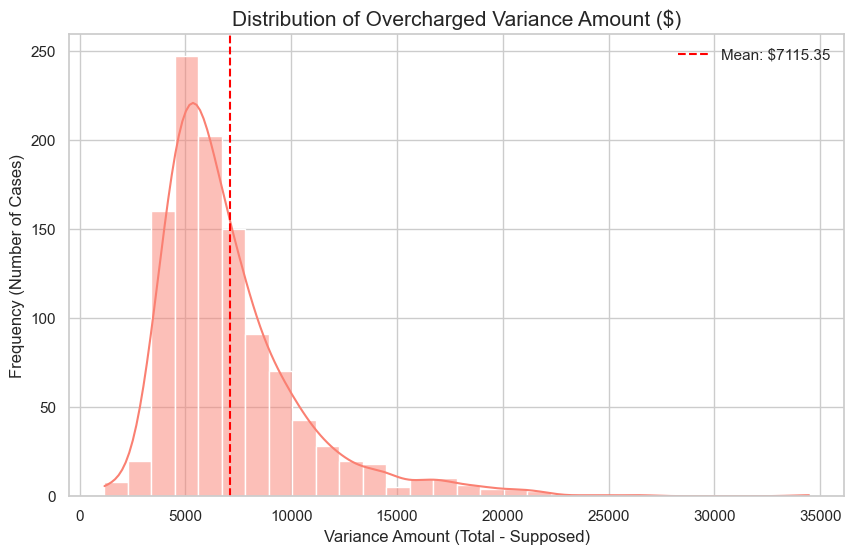

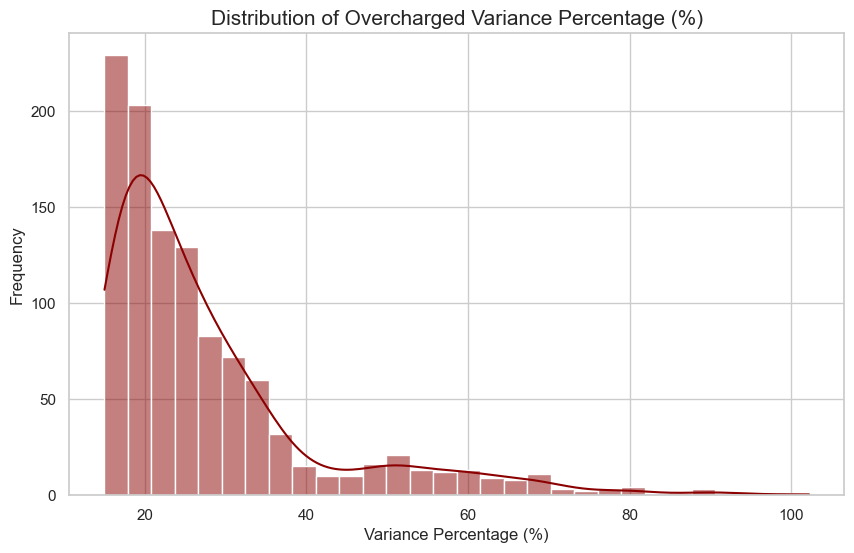

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the data to only include overcharged entries
overcharged_data = df_processed[df_processed['is_overcharged'] == True]

# 2. Set the aesthetic style
sns.set_theme(style="whitegrid")

# 3. Create the plot for Variance Amount
plt.figure(figsize=(10, 6))
sns.histplot(overcharged_data['variance_amount'], kde=True, color='salmon', bins=30)

# Add titles and labels
plt.title('Distribution of Overcharged Variance Amount ($)', fontsize=15)
plt.xlabel('Variance Amount (Total - Supposed)', fontsize=12)
plt.ylabel('Frequency (Number of Cases)', fontsize=12)

# Optional: Add a vertical line for the average variance
plt.axvline(overcharged_data['variance_amount'].mean(), color='red', linestyle='--', label=f'Mean: ${overcharged_data["variance_amount"].mean():.2f}')
plt.legend()

plt.show()

# 4. Create a plot for Variance Percentage (often more insightful)
plt.figure(figsize=(10, 6))
sns.histplot(overcharged_data['variance_percentage'], kde=True, color='darkred', bins=30)
plt.title('Distribution of Overcharged Variance Percentage (%)', fontsize=15)
plt.xlabel('Variance Percentage (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

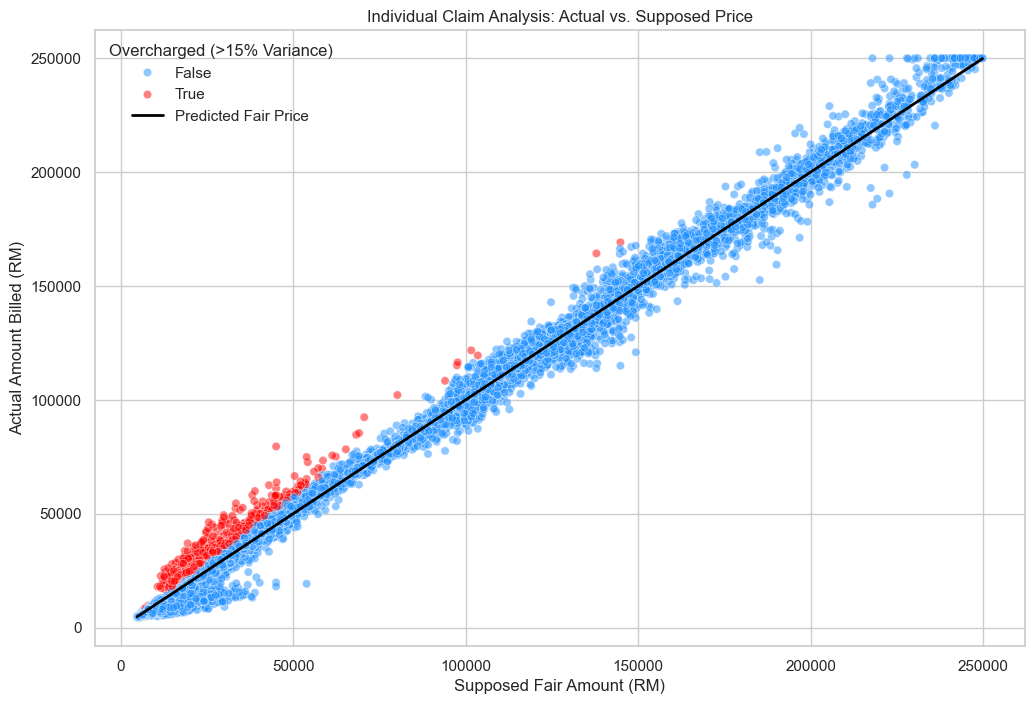

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Scatter plot of EVERY entry
sns.scatterplot(data=df_processed, x='supposed_claim_amount', y='total_claim_amount', 
                hue='is_overcharged', palette={True: 'red', False: 'dodgerblue'}, alpha=0.5)

# The "Fair Price" Line
line_coords = [df_processed['supposed_claim_amount'].min(), df_processed['supposed_claim_amount'].max()]
plt.plot(line_coords, line_coords, color='black', lw=2, label='Predicted Fair Price')

plt.title('Individual Claim Analysis: Actual vs. Supposed Price')
plt.xlabel('Supposed Fair Amount (RM)')
plt.ylabel('Actual Amount Billed (RM)')
plt.legend(title="Overcharged (>15% Variance)")
plt.show()

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Prepare Features (Ensure DRG_Group is included)
# We use the encoded version of your features
X_eval = X 
y_eval = df_processed['total_claim_amount']

# 2. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_eval, y_eval, test_size=0.2, random_state=42)

# 3. Train the Evaluator Model
eval_rf = RandomForestRegressor(n_estimators=200, random_state=42)
eval_rf.fit(X_train, y_train)

# 4. Predict on the Test Set (Data the model hasn't seen)
y_pred_test = eval_rf.predict(X_test)

# 5. Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("--- Random Forest Regressor Accuracy Report ---")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): RM {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): RM {rmse:.2f}")

--- Random Forest Regressor Accuracy Report ---
R-squared (R2): 0.9695
Mean Absolute Error (MAE): RM 6773.48
Root Mean Squared Error (RMSE): RM 9874.69


In [31]:
region_stats = df_processed.groupby('region').agg({
    'total_claim_amount': ['mean', 'median'],
    'supposed_claim_amount': ['mean', 'median']
})

region_stats.columns = ['orig_mean', 'orig_median', 'pred_mean', 'pred_median']

region_stats['mean_ratio'] = region_stats['orig_mean'] / region_stats['pred_mean']
region_stats['median_ratio'] = region_stats['orig_median'] / region_stats['pred_median']

region_stats.index = label_encoders['region'].inverse_transform(region_stats.index)

print("Regional Price Ratios:")
print(region_stats[['mean_ratio', 'median_ratio']])

Regional Price Ratios:
               mean_ratio  median_ratio
Central          1.001230      1.030252
East Coast       0.999760      1.036997
East Malaysia    0.995621      1.021312
Northern         1.001300      1.044553
Southern         1.002776      1.029574


In [32]:
df_processed['region_name'] = label_encoders['region'].inverse_transform(df_processed['region'])

df_processed['region_name'] = df_processed['region_name'].astype(str)

region_stats.index = region_stats.index.astype(str)

df_processed = df_processed.merge(region_stats[['mean_ratio']], left_on='region_name', right_index=True, how='left')

df_processed.head()

df_processed['is_overcharged_regional'] = (df_processed['supposed_claim_amount'] / df_processed['total_claim_amount']) > df_processed['mean_ratio']

In [33]:
overcharged_stats = df_processed.groupby('region_name')['is_overcharged_regional'].agg(['sum', 'count']).rename(
    columns={'sum': 'overcharged_count', 'count': 'total_cases'}

)
overcharged_stats['overcharged_percentage'] = (overcharged_stats['overcharged_count'] / overcharged_stats['total_cases']) * 100

print("--- Overcharged Cases by Region ---")
print(overcharged_stats)

--- Overcharged Cases by Region ---
               overcharged_count  total_cases  overcharged_percentage
region_name                                                          
Central                     1737         3541               49.053940
East Coast                  1985         3840               51.692708
East Malaysia               2180         3771               57.809600
Northern                    2486         5075               48.985222
Southern                    1800         3773               47.707395


In [34]:
private_hospitals = df_processed[df_processed['hospital_type'] == 1].copy()

private_hospitals['overcharge_ratio'] = private_hospitals['supposed_claim_amount'] / private_hospitals['total_claim_amount']

hospital_stats = private_hospitals.groupby('hospital_name').agg(
    overcharge_frequency=('is_overcharged_regional', 'mean'),
    median_magnitude=('overcharge_ratio', 'median')
)

hospital_stats['norm_freq'] = (hospital_stats['overcharge_frequency'] - hospital_stats['overcharge_frequency'].min()) / \
                              (hospital_stats['overcharge_frequency'].max() - hospital_stats['overcharge_frequency'].min() + 1e-9)

hospital_stats['norm_mag'] = (hospital_stats['median_magnitude'] - hospital_stats['median_magnitude'].min()) / \
                             (hospital_stats['median_magnitude'].max() - hospital_stats['median_magnitude'].min() + 1e-9)

hospital_stats['risk_score'] = (hospital_stats['norm_freq'] * 0.5) + (hospital_stats['norm_mag'] * 0.5)

tier_threshold = hospital_stats['risk_score'].quantile(0.2)
hospital_stats['hospital_tier'] = np.where(hospital_stats['risk_score'] >= tier_threshold, 'Tier 1', 'Tier 2')

print("--- Tiered Private Hospitals (Risk-Severity Matrix) ---")
print(hospital_stats[['hospital_tier', 'overcharge_frequency', 'median_magnitude', 'risk_score']].sort_values(by='risk_score', ascending=False))

--- Tiered Private Hospitals (Risk-Severity Matrix) ---
              hospital_tier  overcharge_frequency  median_magnitude  \
hospital_name                                                         
4                    Tier 1              0.642424          1.011344   
44                   Tier 1              0.589286          1.007641   
59                   Tier 1              0.577922          1.003677   
47                   Tier 1              0.576190          1.003378   
56                   Tier 1              0.548780          1.005280   
50                   Tier 1              0.572254          1.003468   
34                   Tier 1              0.563536          1.002789   
55                   Tier 1              0.557292          1.001604   
1                    Tier 1              0.536585          1.000330   
2                    Tier 1              0.501155          1.001602   
33                   Tier 1              0.501706          1.001373   
46                   